# Chapter IV — Side-Loaded Plate (Missing Data / Subregion)

This notebook runs inverse identification using **only measurement data from a subregion** of the plate domain.

Configuration mirrors the legacy script intent:
- FEM-backed measurements (`source=fem`)
- Displacement measurements
- Subregion: `[0.1, 0.6, 0.1, 0.6]`
- Stress integral constraint enabled
- Stress boundary condition disabled

In [19]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config
import phd.models.cm.side_loaded_plate as slp
from phd.plot import get_current_config as plt_cfg, book_config

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")


PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "01_side_loaded_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/r2d2/code/PhD


In [28]:
def build_missing_data_cfg(seed: int = 0):
    cfg = load_config("side_loaded_plate")

    cfg.seed = seed
    cfg.task.type = "inverse"

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 3
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32
    cfg.model.architecture.mlp_type = "modified_mlp"

    cfg.problem.material.law = "isotropic"
    cfg.problem.geometry.length = 100.0  # selects 100x100mm FEM dataset
    cfg.problem.loading.m = 0.3
    cfg.problem.loading.b = 50.0

    cfg.training.n_iter = 40000
    cfg.training.lr = 1e-3
    cfg.training.lr_decay = ["warmup cosine", 1e-4, 5e-3, 1000, 30000, 1e-4]
    cfg.training.log_every = 500
    cfg.training.num_domain = 150**2
    cfg.training.coord_normalization = True
    cfg.training.stress_integral = True
    cfg.training.stress_bc = False
    cfg.training.loss_normalization.scheme = "grad_norm"
    cfg.training.loss_weights = [1.0] * 5 + [1e2] * 2 + [1.0]  # higher weight on measurement losses

    cfg.task.inverse.measurements.source = "fem"
    cfg.task.inverse.measurements.type = "displacement"
    cfg.task.inverse.measurements.n_observations.x = 40
    cfg.task.inverse.measurements.n_observations.y = 40
    cfg.task.inverse.measurements.dic.region = [0.1, 0.6, 0.1, 0.6]
    cfg.task.inverse.measurements.noise_ratio = 1e-4
    # cfg.task.inverse.training_factors.isotropic.E = 5.0
    # cfg.task.inverse.training_factors.isotropic.nu = 5.0

    cfg.problem.log_fields = ["Ux", "Uy", "Sxx", "Syy", "Sxy"]

    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.results.experiment_name = "missing_data_subregion"
    cfg.results.save_on_disk = True

    return cfg


cfg_preview = build_missing_data_cfg(seed=0)
print(f"Geometry length: {cfg_preview.problem.geometry.length}")
print(f"Measurements: {cfg_preview.task.inverse.measurements.type}")
print(f"Region: {list(cfg_preview.task.inverse.measurements.dic.region)}")

Geometry length: 100.0
Measurements: displacement
Region: [0.1, 0.6, 0.1, 0.6]


In [29]:
# Run or load
run_mode = "run"  # "run" or "load"
run_name = "missing_data_subregion"

if run_mode == "run":
    cfg = build_missing_data_cfg(seed=0)
    results = slp.train(cfg)
    run_dir = slp.save_run_data(results, run_name=run_name, base_dir=cfg.results.base_dir)
else:
    results = slp.load_run(run_name, base_dir=PROJECT_ROOT / "results")
    run_dir = Path(results["run_dir"])

print(f"Run mode: {run_mode}")
print(f"Run dir: {run_dir}")

runtime = results.get("runtime_metrics", {})
if runtime:
    print(f"Elapsed time [s]: {runtime.get('elapsed_time', float('nan')):.2f}")
    print(f"Iterations/s: {runtime.get('iterations_per_sec', float('nan')):.2f}")

Set the default automatic differentiation to forward mode.
Compiling model...
'compile' took 0.139306 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric   
0         [1.79e-07, 9.78e-08, 5.96e+00, 4.23e-01, 4.04e-01, 1.13e+02, 1.20e+02, 4.23e+07]    [1.79e-07, 9.78e-08, 5.96e+00, 4.23e-01, 4.04e-01, 1.13e+02, 1.20e+02, 4.23e+07]    [1.00e+00]    
100       [2.34e-02, 3.95e-03, 8.69e+00, 7.06e+00, 5.08e+00, 6.12e+01, 4.71e+01, 3.15e+07]    [2.34e-02, 3.95e-03, 8.69e+00, 7.06e+00, 5.08e+00, 6.12e+01, 4.71e+01, 3.15e+07]    [8.66e-01]    

Best model at step 100:
  train loss: 3.15e+07
  test loss: 3.15e+07
  test metric: [8.66e-01]

'train' took 27.257199 s

Applying loss weighting scheme: grad_norm
  base_loss_weights=[1.0, 1.0, 1.0, 1.0, 1.0, 100.0, 100.0, 1.0]
  grad_norms=[0.07205117493867874, 0.013552041724324226, 361.270050

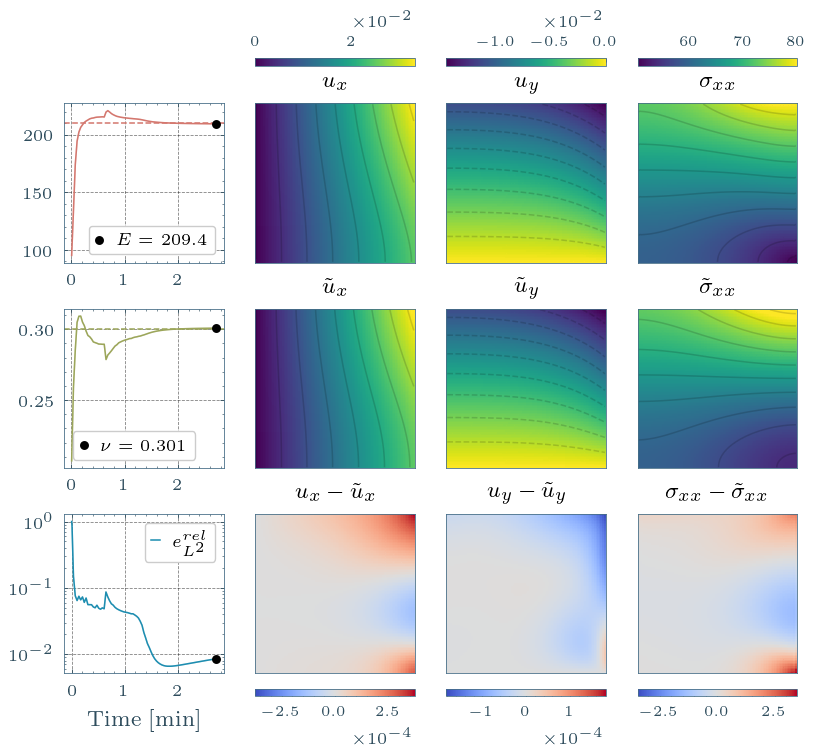

Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/missing_data_subregion_results.png
Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/pdf/missing_data_subregion_results.pdf


In [35]:
# Plot and save results
fig, artists = slp.plot_results(
    results,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Ux", "Uy", "Sxx"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
)
plt.show()

if save_fig:
    figure_name = "missing_data_subregion_results"
    fig.savefig(IMAGE_DIR / f"{figure_name}.png", bbox_inches="tight", dpi=300)
    fig.savefig(PDF_DIR / f"{figure_name}.pdf", bbox_inches="tight")
    print(f"Saved: {IMAGE_DIR / (figure_name + '.png')}")
    print(f"Saved: {PDF_DIR / (figure_name + '.pdf')}")